In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
# load data
ptags = pd.read_csv('./data/pre-train_tags.csv',index_col=0)
pre_training_tags = ptags[ptags['agree'] == 1]


In [21]:
# load data
ftags = pd.read_csv('./data/fine-tune_tags.csv',index_col=0)
fine_tuning_tags = ftags[ftags['agree'] == 1]

# Pre-train exps

In [12]:
tot_tags_pre = pre_training_tags[['7b_ep3_p100_em', 'Cat']].groupby('Cat').count()
tot_tags_pre

,7b_ep3_p100_em
Cat,
c,388
di,164
do,173
l,124
t,50
u,2


In [7]:
ep0_cat_7b = pre_training_tags[pre_training_tags['7b_ep3_p100_em'] == 1 ][['7b_ep3_p100_em', 'Cat']].groupby('Cat').count()
ep0_cat_7b_lo = pre_training_tags[pre_training_tags['7b_lo_ep3_p100_em'] == 1 ][['7b_lo_ep3_p100_em', 'Cat']].groupby('Cat').count()


ep0_cat = ep0_cat_7b.join(ep0_cat_7b_lo, lsuffix='_7b', rsuffix='_lo').loc[['c', 'di', 'do', 'l', 't']]

ep0_cat = ep0_cat.rename(columns={'7b_ep3_p100_em': '7B',
                                  '7b_lo_ep3_p100_em': '7B Lora',
                                  })

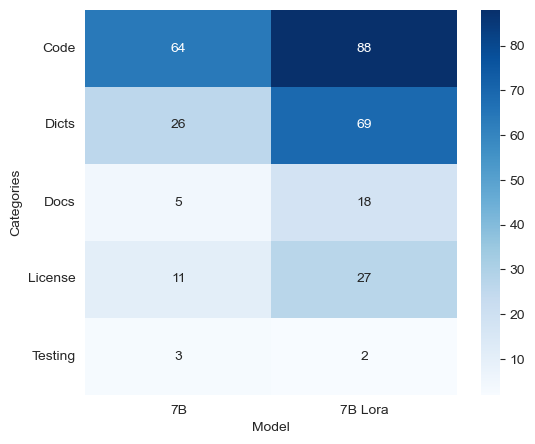

In [8]:
# Create the heatmap
plt.figure(figsize=(6, 5))  # Adjust the size as needed
ax = sns.heatmap(ep0_cat, annot=True, fmt='d', cmap='Blues', cbar=True)

# Set the title and labels
#ax.set_title('Heatmap with Annotations')
ax.set_ylabel('Categories')
ax.set_xlabel('Model')
ax.set_yticklabels(['Code', 'Dicts', 'Docs', 'License', 'Testing'], rotation=0)
ax.set_xticklabels(['7B', '7B Lora'], rotation=0)


# Show the plot
plt.show()

In [11]:
ep0_cat_7b = pre_training_tags[pre_training_tags['7b_ep3_p100_em'] == 1 ][['7b_ep3_p100_em', 'Cat']].groupby('Cat').count()
ep0_cat_7b_lo = pre_training_tags[pre_training_tags['7b_lo_ep3_p100_em'] == 1 ][['7b_lo_ep3_p100_em', 'Cat']].groupby('Cat').count()

ep0_cat_7b['7b_ep3_p100_em'] = ep0_cat_7b['7b_ep3_p100_em'] / tot_tags_pre['7b_ep3_p100_em'] * 100
ep0_cat_7b_lo['7b_lo_ep3_p100_em'] = ep0_cat_7b_lo['7b_lo_ep3_p100_em'] / tot_tags_pre['7b_ep3_p100_em'] * 100


ep0_cat = ep0_cat_7b.join(ep0_cat_7b_lo, lsuffix='_7b', rsuffix='_lo').loc[['c', 'di', 'do', 'l', 't']]

ep0_cat = ep0_cat.rename(columns={'7b_ep3_p100_em': '7B',
                                  '7b_lo_ep3_p100_em': '7B Lora',
                                  })

ep0_cat

,7B,7B Lora
Cat,,
c,16.494845,22.680412
di,15.853659,42.073171
do,2.890173,10.404624
l,8.870968,21.774194
t,6.000000,4.000000


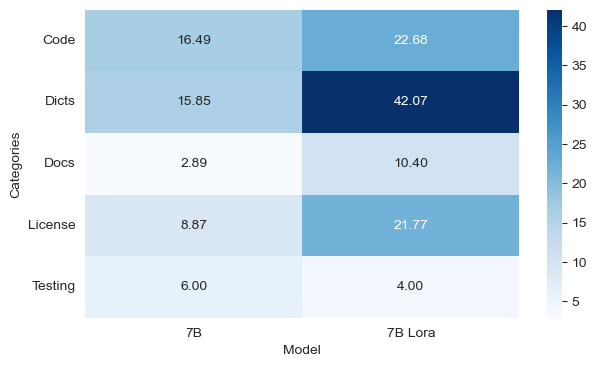

In [38]:
# Create the heatmap
fig, ax = plt.subplots(figsize=(7, 4))  # Adjust the size as needed
ax = sns.heatmap(ep0_cat, annot=True, fmt='.2f', cmap='Blues', cbar=True)

# Set the title and labels
#ax.set_title('Heatmap with Annotations')
ax.set_ylabel('Categories')
ax.set_xlabel('Model')
ax.set_yticklabels(['Code', 'Dicts', 'Docs', 'License', 'Testing'], rotation=0)
ax.set_xticklabels(['7B', '7B Lora'], rotation=0)


# Show the plot
plt.show()
fig.savefig('./lora_tag_mem_ptrain_perc.pdf', format='pdf')


# Fine-tuning

In [23]:
fine_tuning_tags.columns


Index(['prefix_250', 'prefix_200', 'prefix_150', 'prefix_100', 'suffix',
       '7b_lo_ep3_d3', '7b_lo_ep3_d3_em', '7b_lo_ep3_d3_bleu',
       '7b_lo_ep3_d3_meteor', '7b_lo_ep3_d3_rougeL', '7b_ep0_d3',
       '7b_ep0_d3_em', '7b_ep0_d3_bleu', '7b_ep0_d3_meteor',
       '7b_ep0_d3_rougeL', '7b_ep3_d3', '7b_ep3_d3_em', '7b_ep3_d3_bleu',
       '7b_ep3_d3_meteor', '7b_ep3_d3_rougeL', 'eval_sample', 'Cat',
       'Interesting', 'agree'],
      dtype='object')

In [26]:
tot_tags_tune = fine_tuning_tags[['7b_ep0_d3_em', 'Cat']].groupby('Cat').count()
tot_tags_tune

,7b_ep0_d3_em
Cat,
c,223
di,117
do,291
l,284
t,2
u,8


Absolute values

In [27]:
ep3_cat_7b = fine_tuning_tags[fine_tuning_tags['7b_ep3_d3_em'] == 1 ][['7b_ep3_d3_em', 'Cat']].groupby('Cat').count()
ep3_cat_7b_lo = fine_tuning_tags[fine_tuning_tags['7b_lo_ep3_d3_em'] == 1 ][['7b_lo_ep3_d3_em', 'Cat']].groupby('Cat').count()

ep3_cat = ep3_cat_7b.join(ep3_cat_7b_lo, lsuffix='_7b', rsuffix='_lo').fillna(0).loc[['c', 'di', 'do', 'l', 't']]
ep3_cat = ep3_cat.rename(columns={'7b_ep3_d3_em': '7B',
                                  '7b_lo_ep3_d3_em': '7B Lora',
                                  })
ep3_cat

,7B,7B Lora
Cat,,
c,53,2.0
di,52,10.0
do,123,0.0
l,181,86.0
t,1,0.0


Percentage

In [28]:
ep3_cat_7b = fine_tuning_tags[fine_tuning_tags['7b_ep3_d3_em'] == 1][['7b_ep3_d3_em', 'Cat']].groupby('Cat').count()
ep3_cat_7b_lo = fine_tuning_tags[fine_tuning_tags['7b_lo_ep3_d3_em'] == 1][['7b_lo_ep3_d3_em', 'Cat']].groupby('Cat').count()

# Calculate percentages
ep3_cat_7b['7b_ep3_d3_em'] = ep3_cat_7b['7b_ep3_d3_em'] / tot_tags_tune['7b_ep0_d3_em'] * 100
ep3_cat_7b_lo['7b_lo_ep3_d3_em'] = ep3_cat_7b_lo['7b_lo_ep3_d3_em'] / tot_tags_tune['7b_ep0_d3_em'] * 100

ep3_cat = ep3_cat_7b.join(ep3_cat_7b_lo, lsuffix='_7b', rsuffix='_lo', how='outer').fillna(0).loc[['c', 'di', 'do', 'l', 't']]
ep3_cat = ep3_cat.rename(columns={'7b_ep3_d3_em': '7B',
                                  '7b_lo_ep3_d3_em': '7B Lora'})
ep3_cat

,7B,7B Lora
Cat,,
c,23.766816,0.896861
di,44.444444,8.547009
do,42.268041,0.000000
l,63.732394,30.281690
t,50.000000,0.000000


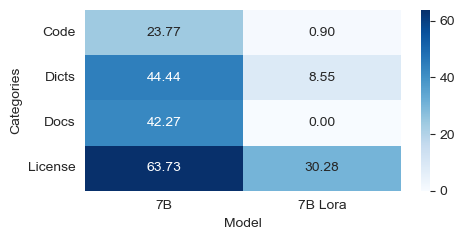

In [33]:
# Create the heatmap
fig, ax = plt.subplots(figsize=(5, 2.5))  # Adjust the size as needed
ax = sns.heatmap(ep3_cat.loc[['c', 'di', 'do', 'l']], annot=True, fmt='.2f', cmap='Blues', cbar=True)

# Set the title and labels
#ax.set_title('Heatmap with Annotations')
ax.set_ylabel('Categories')
ax.set_xlabel('Model')
ax.set_yticklabels(['Code', 'Dicts', 'Docs', 'License'], rotation=0)
ax.set_xticklabels(['7B', '7B Lora'], rotation=0)

fig.tight_layout()
# Show the plot
plt.show()
fig.savefig('./lora_tag_mem_ftune_perc.pdf', format='pdf')